In [ ]:
# EventWise AI: Event-Driven Traffic Congestion Forecasting and Response Planning

## Problem Statement

Political rallies, festivals, sports events, construction activities, vehicle breakdowns, and sudden gatherings create localized traffic congestion and traffic flow disruptions.

Current traffic management systems rely heavily on manual monitoring and reactive decision-making. This project aims to develop an AI-driven traffic intelligence system capable of forecasting traffic risk levels and supporting resource deployment decisions.

## Objectives

- Predict traffic incident severity (High / Low Risk)
- Analyze factors contributing to congestion
- Generate traffic risk intelligence
- Support manpower and barricade deployment recommendations

## Machine Learning Pipeline

Traffic Incident Data
↓
Data Cleaning
↓
Feature Engineering
↓
CatBoost Classifier
+
LightGBM Classifier
↓
Weighted Ensemble
↓
Traffic Risk Prediction
↓
Decision Support Dashboard

## Algorithms Used

1. CatBoost Classifier
2. LightGBM Classifier
3. Weighted Ensemble (40% CatBoost + 60% LightGBM)

## Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- ROC-AUC Score

In [1]:
!pip install -q catboost lightgbm

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from catboost import CatBoostClassifier
import lightgbm as lgb

import joblib

print("All Libraries Loaded Successfully")

All Libraries Loaded Successfully


In [3]:
path = "/kaggle/input/datasets/priyankapanigrahi09/event-driven-traffic-congestion-dataset/Astram event data_anonymized - Astram event data_anonymizedb40ac87(Theme 2 dataset)roun d 2.csv"

df = pd.read_csv(path)

print("Dataset Shape :", df.shape)

df.head()

Dataset Shape : (8173, 46)


,id,event_type,latitude,longitude,endlatitude,endlongitude,address,end_address,event_cause,requires_road_closure,...,resolved_at_address,resolved_at_latitude,resolved_at_longitude,closed_by_id,closed_datetime,resolved_by_id,resolved_datetime,gba_identifier,zone,junction
0,FKID000000,unplanned,13.040004,77.518099,0.000000,0.000000,"Mumbai Bengaluru Highway, Jalahalli Cross Junc...",NaN,vehicle_breakdown,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,FKID000001,unplanned,12.921876,77.645158,0.000000,0.000000,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",NaN,vehicle_breakdown,False,...,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",12.921876,77.645158,NaN,NaN,FKUSR00002,2024-01-30 04:17:46.828355+00,NaN,NaN,NaN
2,FKID000002,unplanned,12.955622,77.585708,0.000000,0.000000,"Lalbagh Main Road, Dr Sri Shantaveera Swami Ci...",NaN,others,False,...,NaN,NaN,NaN,FKUSR00003,2024-01-30 04:56:03.281509+00,NaN,NaN,Bengaluru Central Corporation,Central Zone 2,UrvashiJunction
3,FKID000003,unplanned,13.006147,77.579435,13.006239,77.579516,"Sankey Road, Bashyam Circle, Sadashiva Nagar, ...","Sankey Road, Palace Orchard Upper, Sadashiva N...",tree_fall,True,...,NaN,NaN,NaN,FKUSR00004,2024-03-14 07:42:05.54944+00,NaN,NaN,NaN,NaN,NaN
4,FKID000004,unplanned,12.953980,77.585233,0.000000,0.000000,"Lalbagh Fort Road, Lalbagh Main Gate Junction,...",NaN,vehicle_breakdown,False,...,NaN,NaN,NaN,FKUSR00003,2024-01-30 05:35:17.338283+00,NaN,NaN,NaN,NaN,LalbaghMainGateJunc


In [4]:
print("="*60)
print("DATASET INFO")
print("="*60)

df.info()

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8173 entries, 0 to 8172
Data columns (total 46 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     8173 non-null   object 
 1   event_type             8173 non-null   object 
 2   latitude               8173 non-null   float64
 3   longitude              8173 non-null   float64
 4   endlatitude            8004 non-null   float64
 5   endlongitude           8004 non-null   float64
 6   address                8170 non-null   object 
 7   end_address            687 non-null    object 
 8   event_cause            8173 non-null   object 
 9   requires_road_closure  8173 non-null   bool   
 10  start_datetime         8173 non-null   object 
 11  end_datetime           490 non-null    object 
 12  status                 8173 non-null   object 
 13  authenticated          8173 non-null   object 
 14  modified_datetime      8173 non-null   obje

In [5]:
print(df['priority'].value_counts(dropna=False))
print("\n")
print(df['priority'].unique())

priority
High    5030
Low     3141
NaN        2
Name: count, dtype: int64


['High' 'Low' nan]


In [6]:
# Remove rows where target is missing

df = df.dropna(subset=['priority'])

print("Dataset Shape After Removing Null Target:")
print(df.shape)

print("\nPriority Distribution:")
print(df['priority'].value_counts())

Dataset Shape After Removing Null Target:
(8171, 46)

Priority Distribution:
priority
High    5030
Low     3141
Name: count, dtype: int64


In [7]:
drop_cols = [
    'id',
    'comment',
    'map_file',
    'meta_data',
    'direction',
    'resolved_at_address',
    'resolved_at_latitude',
    'resolved_at_longitude',
    'resolved_by_id',
    'resolved_datetime',
    'assigned_to_police_id',
    'citizen_accident_id',
    'route_path',
    'age_of_truck',
    'reason_breakdown',
    'cargo_material',
    'end_datetime',
    'end_address',
    'closed_datetime',
    'closed_by_id',
    'description',
    'created_by_id',
    'last_modified_by_id',
    'kgid',
    'gba_identifier'
]

df.drop(
    columns=drop_cols,
    inplace=True,
    errors='ignore'
)

print("New Shape:", df.shape)

New Shape: (8171, 21)


In [8]:
# Convert datetime

df['start_datetime'] = pd.to_datetime(
    df['start_datetime'],
    errors='coerce'
)

# Create datetime features

df['hour'] = df['start_datetime'].dt.hour
df['day'] = df['start_datetime'].dt.day
df['month'] = df['start_datetime'].dt.month
df['weekday'] = df['start_datetime'].dt.dayofweek

# Week number
df['weekofyear'] = df['start_datetime'].dt.isocalendar().week

# Fill missing datetime-derived values

datetime_cols = [
    'hour',
    'day',
    'month',
    'weekday',
    'weekofyear'
]

for col in datetime_cols:
    df[col] = df[col].fillna(df[col].median())

print("Datetime Features Created Successfully")

df[['hour','day','month','weekday','weekofyear']].head()

Datetime Features Created Successfully


,hour,day,month,weekday,weekofyear
0,17.0,7.0,3.0,3.0,10
1,4.0,30.0,1.0,1.0,5
2,6.0,11.0,11.0,5.0,45
3,17.0,7.0,3.0,3.0,10
4,4.0,30.0,1.0,1.0,5


In [9]:
features = [
    'event_type',
    'event_cause',
    'requires_road_closure',
    'zone',
    'latitude',
    'longitude',
    'hour',
    'day',
    'month',
    'weekday',
    'weekofyear'
]

target = 'priority'

model_df = df[features + [target]].copy()

print("Model Dataset Shape:", model_df.shape)

model_df.head()

Model Dataset Shape: (8171, 12)


,event_type,event_cause,requires_road_closure,zone,latitude,longitude,hour,day,month,weekday,weekofyear,priority
0,unplanned,vehicle_breakdown,False,NaN,13.040004,77.518099,17.0,7.0,3.0,3.0,10,High
1,unplanned,vehicle_breakdown,False,NaN,12.921876,77.645158,4.0,30.0,1.0,1.0,5,High
2,unplanned,others,False,Central Zone 2,12.955622,77.585708,6.0,11.0,11.0,5.0,45,Low
3,unplanned,tree_fall,True,NaN,13.006147,77.579435,17.0,7.0,3.0,3.0,10,Low
4,unplanned,vehicle_breakdown,False,NaN,12.953980,77.585233,4.0,30.0,1.0,1.0,5,Low


In [10]:
for col in model_df.columns:

    if model_df[col].dtype == 'object':
        model_df[col] = model_df[col].fillna('Unknown')

    else:
        model_df[col] = model_df[col].fillna(
            model_df[col].median()
        )

print("Remaining Missing Values:")
print(model_df.isnull().sum().sum())

Remaining Missing Values:
0


In [11]:
priority_map = {
    'Low': 0,
    'High': 1
}

model_df['priority'] = model_df['priority'].map(priority_map)

print(model_df['priority'].value_counts())
print("\nUnique Classes:", model_df['priority'].unique())

priority
1    5030
0    3141
Name: count, dtype: int64

Unique Classes: [1 0]


In [12]:
freq_cols = [
    'event_type',
    'event_cause',
    'zone',
]

for col in freq_cols:

    freq_map = model_df[col].value_counts()

    model_df[col] = model_df[col].map(freq_map)

print("Frequency Encoding Completed")

Frequency Encoding Completed


In [13]:
model_df['requires_road_closure'] = (
    model_df['requires_road_closure']
    .astype(str)
    .str.lower()
)

model_df['requires_road_closure'] = model_df[
    'requires_road_closure'
].map({
    'true': 1,
    'false': 0
})

model_df['requires_road_closure'] = (
    model_df['requires_road_closure']
    .fillna(0)
)

print(model_df['requires_road_closure'].value_counts())

requires_road_closure
0    7495
1     676
Name: count, dtype: int64


In [14]:
print(model_df.info())

print("\nMissing Values:")
print(model_df.isnull().sum().sum())

display(model_df.head())

<class 'pandas.core.frame.DataFrame'>
Index: 8171 entries, 0 to 8172
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   event_type             8171 non-null   int64  
 1   event_cause            8171 non-null   int64  
 2   requires_road_closure  8171 non-null   int64  
 3   zone                   8171 non-null   int64  
 4   latitude               8171 non-null   float64
 5   longitude              8171 non-null   float64
 6   hour                   8171 non-null   float64
 7   day                    8171 non-null   float64
 8   month                  8171 non-null   float64
 9   weekday                8171 non-null   float64
 10  weekofyear             8171 non-null   UInt32 
 11  priority               8171 non-null   int64  
dtypes: UInt32(1), float64(6), int64(5)
memory usage: 805.9 KB
None

Missing Values:
0


,event_type,event_cause,requires_road_closure,zone,latitude,longitude,hour,day,month,weekday,weekofyear,priority
0,7704,4894,0,4728,13.040004,77.518099,17.0,7.0,3.0,3.0,10,1
1,7704,4894,0,4728,12.921876,77.645158,4.0,30.0,1.0,1.0,5,1
2,7704,638,0,623,12.955622,77.585708,6.0,11.0,11.0,5.0,45,0
3,7704,284,1,4728,13.006147,77.579435,17.0,7.0,3.0,3.0,10,0
4,7704,4894,0,4728,12.953980,77.585233,4.0,30.0,1.0,1.0,5,0


In [15]:
X = model_df.drop('priority', axis=1)

y = model_df['priority']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (8171, 11)
Target Shape: (8171,)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (6536, 11)
Testing Shape  : (1635, 11)


In [17]:
print("Training Target Distribution")
print(y_train.value_counts())

print("\nTesting Target Distribution")
print(y_test.value_counts())

print("\nMissing Values in X_train")
print(X_train.isnull().sum().sum())

print("\nMissing Values in X_test")
print(X_test.isnull().sum().sum())

Training Target Distribution
priority
1    4024
0    2512
Name: count, dtype: int64

Testing Target Distribution
priority
1    1006
0     629
Name: count, dtype: int64

Missing Values in X_train
0

Missing Values in X_test
0


In [18]:
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=100
)

cat_model.fit(
    X_train,
    y_train
)

print("CatBoost Training Completed")

0:	total: 55.1ms	remaining: 27.5s
100:	total: 325ms	remaining: 1.28s
200:	total: 605ms	remaining: 901ms
300:	total: 882ms	remaining: 583ms
400:	total: 1.16s	remaining: 286ms
499:	total: 1.44s	remaining: 0us
CatBoost Training Completed


In [19]:
cat_pred = cat_model.predict(X_test)

cat_prob = cat_model.predict_proba(X_test)[:,1]

In [20]:
print("CATBOOST RESULTS")
print("="*50)

print("Accuracy  :", round(accuracy_score(y_test, cat_pred),4))
print("Precision :", round(precision_score(y_test, cat_pred),4))
print("Recall    :", round(recall_score(y_test, cat_pred),4))
print("F1 Score  :", round(f1_score(y_test, cat_pred),4))
print("ROC AUC   :", round(roc_auc_score(y_test, cat_prob),4))

CATBOOST RESULTS
Accuracy  : 0.9609
Precision : 0.9486
Recall    : 0.9901
F1 Score  : 0.9689
ROC AUC   : 0.9943


In [21]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    random_state=42
)

lgb_model.fit(
    X_train,
    y_train
)

print("LightGBM Training Completed")

[LightGBM] [Info] Number of positive: 4024, number of negative: 2512
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001130 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 637
[LightGBM] [Info] Number of data points in the train set: 6536, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.615667 -> initscore=0.471197
[LightGBM] [Info] Start training from score 0.471197
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

In [22]:
lgb_pred = lgb_model.predict(X_test)

lgb_prob = lgb_model.predict_proba(X_test)[:,1]

In [23]:
print("LIGHTGBM RESULTS")
print("="*50)

print("Accuracy  :", round(accuracy_score(y_test, lgb_pred),4))
print("Precision :", round(precision_score(y_test, lgb_pred),4))
print("Recall    :", round(recall_score(y_test, lgb_pred),4))
print("F1 Score  :", round(f1_score(y_test, lgb_pred),4))
print("ROC AUC   :", round(roc_auc_score(y_test, lgb_prob),4))

LIGHTGBM RESULTS
Accuracy  : 0.9682
Precision : 0.9622
Recall    : 0.9871
F1 Score  : 0.9745
ROC AUC   : 0.9937


In [24]:
ensemble_prob = (
    0.4 * cat_prob +
    0.6 * lgb_prob
)

ensemble_pred = (
    ensemble_prob > 0.5
).astype(int)

print("Ensemble Prediction Created")

Ensemble Prediction Created


In [25]:
print("ENSEMBLE RESULTS")
print("="*50)

print("Accuracy  :", round(accuracy_score(y_test, ensemble_pred),4))
print("Precision :", round(precision_score(y_test, ensemble_pred),4))
print("Recall    :", round(recall_score(y_test, ensemble_pred),4))
print("F1 Score  :", round(f1_score(y_test, ensemble_pred),4))
print("ROC AUC   :", round(roc_auc_score(y_test, ensemble_prob),4))

ENSEMBLE RESULTS
Accuracy  : 0.9664
Precision : 0.9577
Recall    : 0.9891
F1 Score  : 0.9731
ROC AUC   : 0.9952


In [26]:
print(
    classification_report(
        y_test,
        ensemble_pred
    )
)

              precision    recall  f1-score   support

           0       0.98      0.93      0.96       629
           1       0.96      0.99      0.97      1006

    accuracy                           0.97      1635
   macro avg       0.97      0.96      0.96      1635
weighted avg       0.97      0.97      0.97      1635



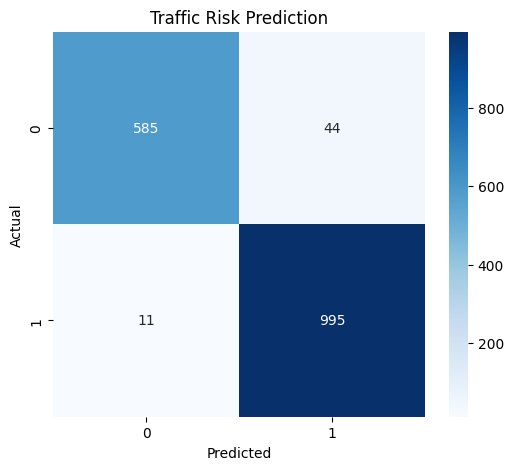

In [27]:
cm = confusion_matrix(
    y_test,
    ensemble_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Traffic Risk Prediction")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

<Figure size 1000x600 with 0 Axes>

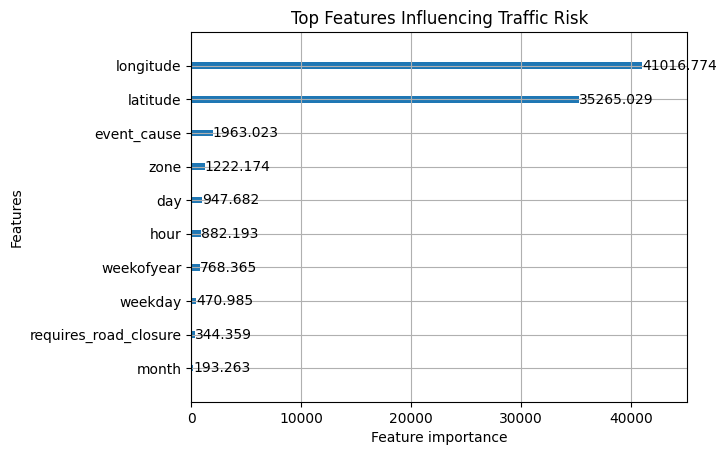

In [28]:
plt.figure(figsize=(10,6))

lgb.plot_importance(
    lgb_model,
    max_num_features=10,
    importance_type='gain'
)

plt.title("Top Features Influencing Traffic Risk")

plt.show()

<Figure size 1200x800 with 0 Axes>

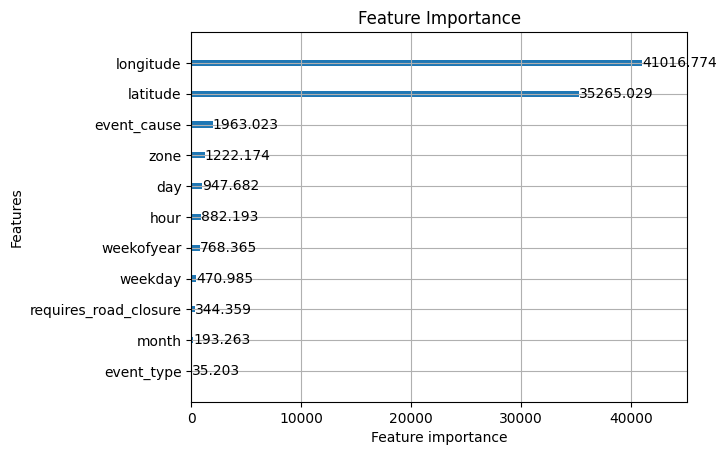

In [29]:
plt.figure(figsize=(12,8))

lgb.plot_importance(
    lgb_model,
    max_num_features=15,
    importance_type='gain'
)

plt.title("Feature Importance")
plt.show()

In [30]:
dashboard_df = X_test.copy()

dashboard_df['Risk_Probability'] = ensemble_prob

dashboard_df['Risk_Score'] = (
    dashboard_df['Risk_Probability'] * 100
).round(2)

dashboard_df.head()

,event_type,event_cause,requires_road_closure,zone,latitude,longitude,hour,day,month,weekday,weekofyear,Risk_Probability,Risk_Score
3557,7704,4894,0,4728,13.053755,77.593184,6.0,2.0,4.0,1.0,14,0.978067,97.81
4511,7704,4894,0,4728,13.019773,77.708735,2.0,22.0,1.0,0.0,4,0.000682,0.07
2423,7704,4894,0,4728,13.044368,77.508793,23.0,20.0,3.0,2.0,12,0.977733,97.77
2287,7704,4894,0,4728,12.987919,77.574147,7.0,1.0,3.0,4.0,9,0.020090,2.01
2098,7704,365,0,4728,12.943404,77.577879,21.0,27.0,2.0,1.0,9,0.004931,0.49


In [31]:
def risk_category(score):

    if score >= 80:
        return "High"

    elif score >= 50:
        return "Medium"

    else:
        return "Low"


dashboard_df['Risk_Category'] = (
    dashboard_df['Risk_Score']
    .apply(risk_category)
)

dashboard_df.head()

,event_type,event_cause,requires_road_closure,zone,latitude,longitude,hour,day,month,weekday,weekofyear,Risk_Probability,Risk_Score,Risk_Category
3557,7704,4894,0,4728,13.053755,77.593184,6.0,2.0,4.0,1.0,14,0.978067,97.81,High
4511,7704,4894,0,4728,13.019773,77.708735,2.0,22.0,1.0,0.0,4,0.000682,0.07,Low
2423,7704,4894,0,4728,13.044368,77.508793,23.0,20.0,3.0,2.0,12,0.977733,97.77,High
2287,7704,4894,0,4728,12.987919,77.574147,7.0,1.0,3.0,4.0,9,0.020090,2.01,Low
2098,7704,365,0,4728,12.943404,77.577879,21.0,27.0,2.0,1.0,9,0.004931,0.49,Low


In [32]:
dashboard_df['Congestion_Score'] = (
    dashboard_df['Risk_Score'] * 0.9 +
    dashboard_df['requires_road_closure'] * 10
)

dashboard_df['Congestion_Score'] = (
    dashboard_df['Congestion_Score']
    .clip(0,100)
)

dashboard_df.head()

,event_type,event_cause,requires_road_closure,zone,latitude,longitude,hour,day,month,weekday,weekofyear,Risk_Probability,Risk_Score,Risk_Category,Congestion_Score
3557,7704,4894,0,4728,13.053755,77.593184,6.0,2.0,4.0,1.0,14,0.978067,97.81,High,88.029
4511,7704,4894,0,4728,13.019773,77.708735,2.0,22.0,1.0,0.0,4,0.000682,0.07,Low,0.063
2423,7704,4894,0,4728,13.044368,77.508793,23.0,20.0,3.0,2.0,12,0.977733,97.77,High,87.993
2287,7704,4894,0,4728,12.987919,77.574147,7.0,1.0,3.0,4.0,9,0.020090,2.01,Low,1.809
2098,7704,365,0,4728,12.943404,77.577879,21.0,27.0,2.0,1.0,9,0.004931,0.49,Low,0.441


In [33]:
dashboard_df['Estimated_Delay_Minutes'] = (
    5 +
    dashboard_df['Congestion_Score'] * 0.6
).astype(int)

dashboard_df.head()

,event_type,event_cause,requires_road_closure,zone,latitude,longitude,hour,day,month,weekday,weekofyear,Risk_Probability,Risk_Score,Risk_Category,Congestion_Score,Estimated_Delay_Minutes
3557,7704,4894,0,4728,13.053755,77.593184,6.0,2.0,4.0,1.0,14,0.978067,97.81,High,88.029,57
4511,7704,4894,0,4728,13.019773,77.708735,2.0,22.0,1.0,0.0,4,0.000682,0.07,Low,0.063,5
2423,7704,4894,0,4728,13.044368,77.508793,23.0,20.0,3.0,2.0,12,0.977733,97.77,High,87.993,57
2287,7704,4894,0,4728,12.987919,77.574147,7.0,1.0,3.0,4.0,9,0.020090,2.01,Low,1.809,6
2098,7704,365,0,4728,12.943404,77.577879,21.0,27.0,2.0,1.0,9,0.004931,0.49,Low,0.441,5


In [34]:
def resource_plan(score):

    if score >= 85:
        return pd.Series([12,15,4])

    elif score >= 65:
        return pd.Series([8,10,2])

    elif score >= 40:
        return pd.Series([4,4,1])

    else:
        return pd.Series([2,2,0])


dashboard_df[
    [
        'Police_Personnel',
        'Barricades',
        'Diversion_Routes'
    ]
] = dashboard_df[
    'Congestion_Score'
].apply(resource_plan)

dashboard_df.head()

,event_type,event_cause,requires_road_closure,zone,latitude,longitude,hour,day,month,weekday,weekofyear,Risk_Probability,Risk_Score,Risk_Category,Congestion_Score,Estimated_Delay_Minutes,Police_Personnel,Barricades,Diversion_Routes
3557,7704,4894,0,4728,13.053755,77.593184,6.0,2.0,4.0,1.0,14,0.978067,97.81,High,88.029,57,12,15,4
4511,7704,4894,0,4728,13.019773,77.708735,2.0,22.0,1.0,0.0,4,0.000682,0.07,Low,0.063,5,2,2,0
2423,7704,4894,0,4728,13.044368,77.508793,23.0,20.0,3.0,2.0,12,0.977733,97.77,High,87.993,57,12,15,4
2287,7704,4894,0,4728,12.987919,77.574147,7.0,1.0,3.0,4.0,9,0.020090,2.01,Low,1.809,6,2,2,0
2098,7704,365,0,4728,12.943404,77.577879,21.0,27.0,2.0,1.0,9,0.004931,0.49,Low,0.441,5,2,2,0


In [35]:
dashboard_df[
    [
        'Risk_Score',
        'Risk_Category',
        'Congestion_Score',
        'Estimated_Delay_Minutes',
        'Police_Personnel',
        'Barricades',
        'Diversion_Routes'
    ]
].head(20)

,Risk_Score,Risk_Category,Congestion_Score,Estimated_Delay_Minutes,Police_Personnel,Barricades,Diversion_Routes
3557,97.81,High,88.029,57,12,15,4
4511,0.07,Low,0.063,5,2,2,0
2423,97.77,High,87.993,57,12,15,4
2287,2.01,Low,1.809,6,2,2,0
2098,0.49,Low,0.441,5,2,2,0
5587,97.48,High,87.732,57,12,15,4
7196,48.87,Low,43.983,31,4,4,1
3495,94.78,High,85.302,56,12,15,4
4912,98.10,High,88.290,57,12,15,4
322,98.16,High,88.344,58,12,15,4


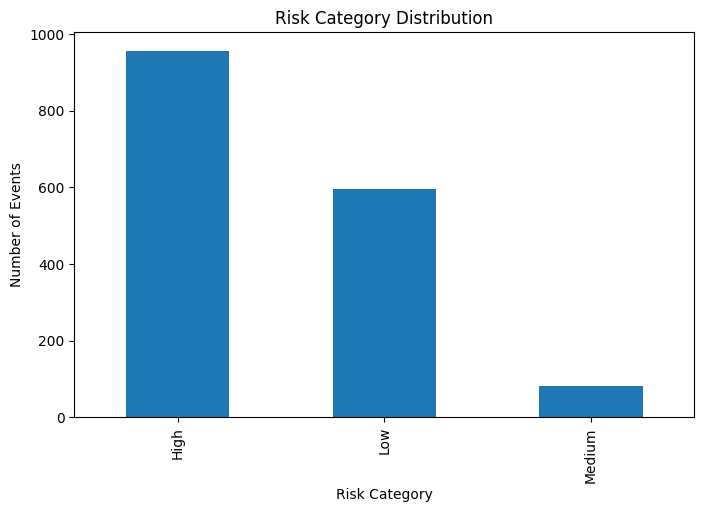

In [36]:
plt.figure(figsize=(8,5))

dashboard_df['Risk_Category'].value_counts().plot(kind='bar')

plt.title("Risk Category Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Events")

plt.show()

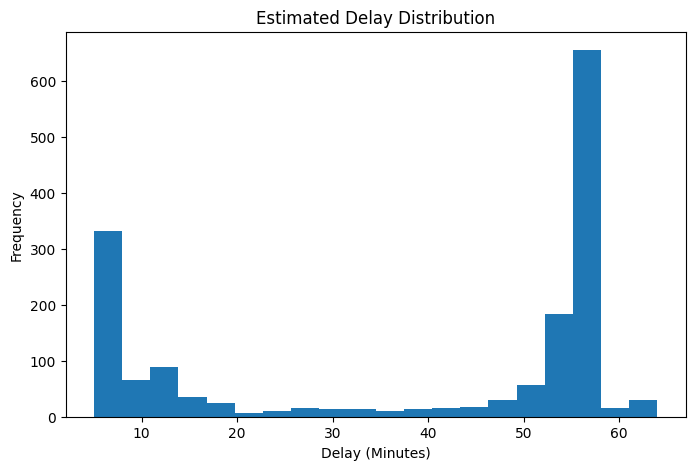

In [37]:
plt.figure(figsize=(8,5))

plt.hist(
    dashboard_df['Estimated_Delay_Minutes'],
    bins=20
)

plt.title("Estimated Delay Distribution")
plt.xlabel("Delay (Minutes)")
plt.ylabel("Frequency")

plt.show()

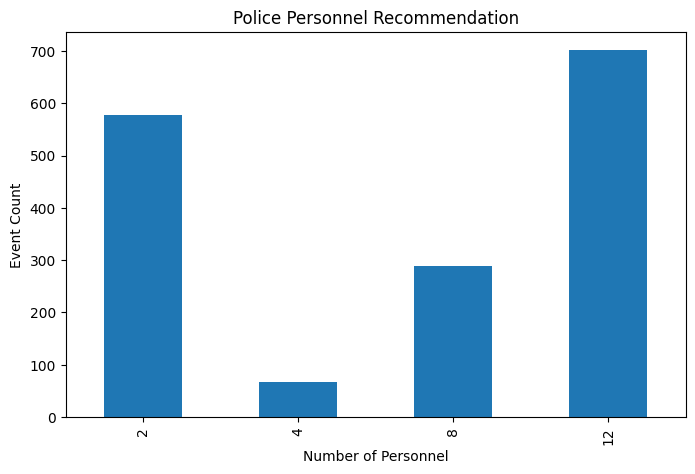

In [38]:
plt.figure(figsize=(8,5))

dashboard_df['Police_Personnel'].value_counts().sort_index().plot(
    kind='bar'
)

plt.title("Police Personnel Recommendation")
plt.xlabel("Number of Personnel")
plt.ylabel("Event Count")

plt.show()

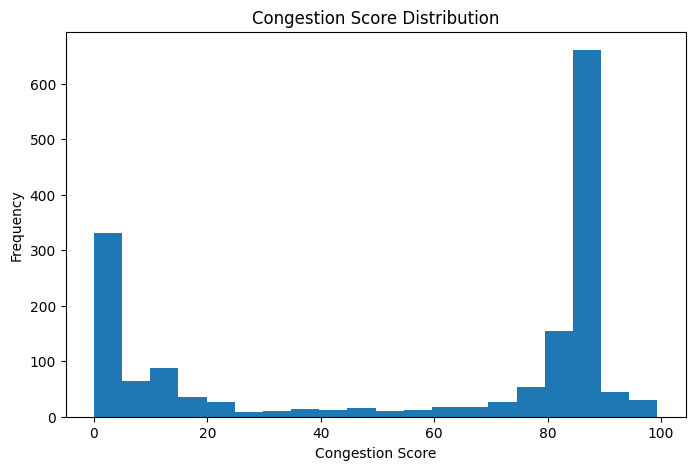

In [39]:
plt.figure(figsize=(8,5))

plt.hist(
    dashboard_df['Congestion_Score'],
    bins=20
)

plt.title("Congestion Score Distribution")
plt.xlabel("Congestion Score")
plt.ylabel("Frequency")

plt.show()

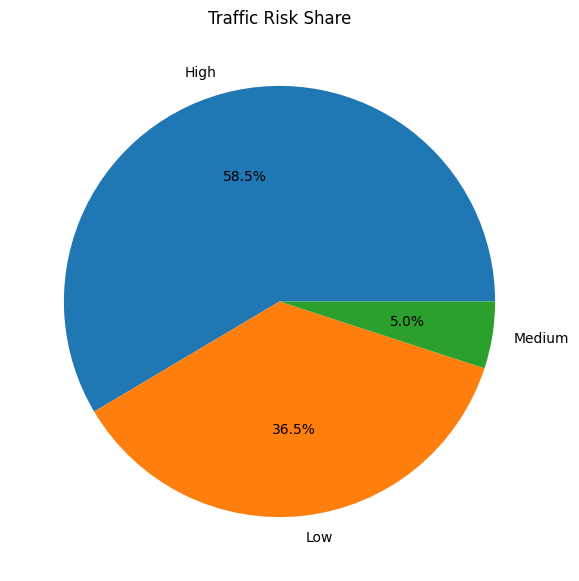

In [40]:
plt.figure(figsize=(7,7))

dashboard_df['Risk_Category'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")
plt.title("Traffic Risk Share")

plt.show()

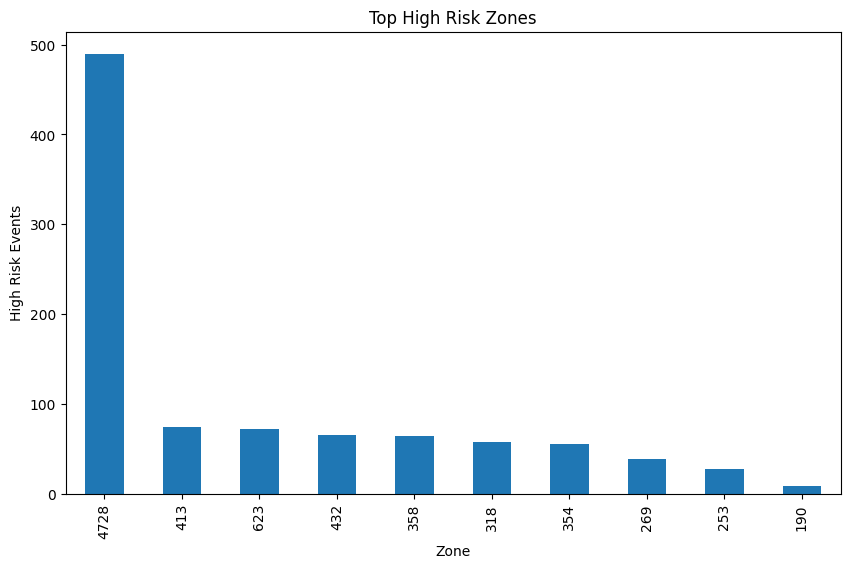

In [41]:
high_risk = dashboard_df[
    dashboard_df['Risk_Category'] == 'High'
]

plt.figure(figsize=(10,6))

high_risk['zone'].value_counts().head(10).plot(
    kind='bar'
)

plt.title("Top High Risk Zones")
plt.xlabel("Zone")
plt.ylabel("High Risk Events")

plt.show()

In [42]:
print(dashboard_df.shape)

dashboard_df.head()

(1635, 19)


,event_type,event_cause,requires_road_closure,zone,latitude,longitude,hour,day,month,weekday,weekofyear,Risk_Probability,Risk_Score,Risk_Category,Congestion_Score,Estimated_Delay_Minutes,Police_Personnel,Barricades,Diversion_Routes
3557,7704,4894,0,4728,13.053755,77.593184,6.0,2.0,4.0,1.0,14,0.978067,97.81,High,88.029,57,12,15,4
4511,7704,4894,0,4728,13.019773,77.708735,2.0,22.0,1.0,0.0,4,0.000682,0.07,Low,0.063,5,2,2,0
2423,7704,4894,0,4728,13.044368,77.508793,23.0,20.0,3.0,2.0,12,0.977733,97.77,High,87.993,57,12,15,4
2287,7704,4894,0,4728,12.987919,77.574147,7.0,1.0,3.0,4.0,9,0.020090,2.01,Low,1.809,6,2,2,0
2098,7704,365,0,4728,12.943404,77.577879,21.0,27.0,2.0,1.0,9,0.004931,0.49,Low,0.441,5,2,2,0


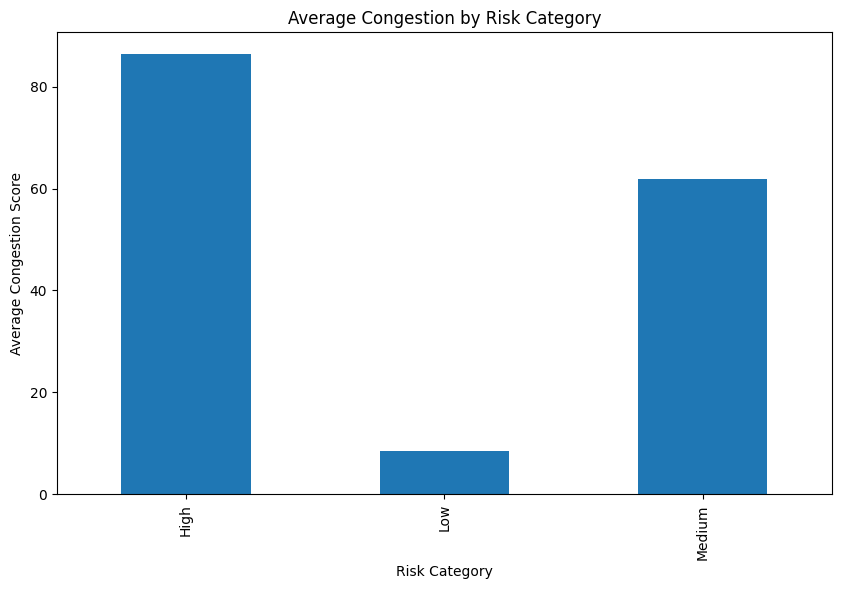

In [43]:
plt.figure(figsize=(10,6))

dashboard_df.groupby(
    'Risk_Category'
)['Congestion_Score'].mean().plot(
    kind='bar'
)

plt.title("Average Congestion by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Average Congestion Score")

plt.show()

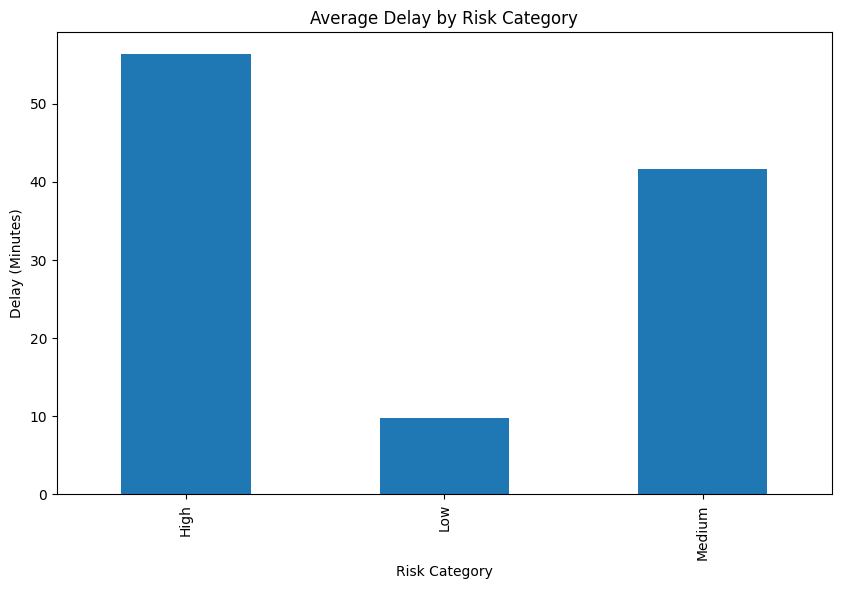

In [44]:
plt.figure(figsize=(10,6))

dashboard_df.groupby(
    'Risk_Category'
)['Estimated_Delay_Minutes'].mean().plot(
    kind='bar'
)

plt.title("Average Delay by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Delay (Minutes)")

plt.show()

In [45]:
dashboard_df.to_csv(
    "traffic congestion dashboard_output.csv",
    index=False
)

print("Export Successful")

Export Successful
